# **Instituto Tecnológico y de Estudios Superiores de Monterrey**

# **Actividad 5 | Visualización de Resultados** Equipo 38

<table>
  <tr>

- ### Salvador Hernández Medrano **A01796607**  
- ### Emmanuel Merida Toledo  **A01795858**  
- ### Francisco Gómez Rubio **A00710437**  
- ### Josué Daniel Lescano López **A01367234**

    
  </tr>
</table>

## Análisis de grandes volúmenes de datos

**22 de Junio de 2025**

**Dataset**: Precios OHLCV de 234 criptomonedas (~125M registros)



# **Configuración inicial y Dataset Seleccionado**


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Se decide trabajar sobre el dataset Bitcoin +233 Crypto Coins Prices.
Este conjunto de datos es particularmente valioso para quienes buscan aplicar análisis técnico en el ámbito de las criptomonedas. La estructura OHLCV permite la construcción de gráficos de velas japonesas, identificación de patrones de precios y evaluación de indicadores técnicos como medias móviles, RSI y MACD. Además, la amplitud del conjunto de datos, que abarca una amplia gama de criptomonedas, facilita la comparación de comportamientos de mercado entre diferentes activos digitales.
El creador del conjunto de datos, Oleg Shpagin, ha proporcionado notebooks en Kaggle que demuestran cómo utilizar estos datos para crear gráficos de velas y desarrollar estrategias de trading. Por ejemplo, en el notebook "How to draw cool candlestick chart", se muestra cómo visualizar los datos OHLCV de manera efectiva.

**Revisión del dataset.**

**Repositorio:**

https://www.kaggle.com/datasets/olegshpagin/crypto-coins-prices-ohlcv/data

**Descripción general:**

El dataset contiene precios históricos de 234 criptomonedas (incluyendo Bitcoin y altcoins), con los siguientes campos para cada transacción:
- Open (precio de apertura)
- High (precio máximo)
- Low (precio mínimo)
- Close (precio de cierre)
- Volume (volumen operado)

Estos datos están disponibles en diferentes marcos de tiempo: W1 (Semanal), D1 (Diaria), H4 (4 horas), H1 (1 hora), M30 (30 minutos), M15 (15 minutos) y M5 (cinco minutos).

**Tamaño:** Aproximadamente **~9 GB.**

## 📁 Formato

Archivos en formato **CSV** organizados en subdirectorios por intervalo de tiempo.

---

## 📂 Estructura de directorios

```
.
├── D1
├── H1
├── H4
├── M15
├── M30
├── M5
├── W1
├── ReadMe.md
└── Screenshot.jpg
```

Cada carpeta contiene múltiples archivos CSV, uno por criptomoneda y frecuencia.

---

## ⚙️ Proceso de preparación del dataset

- Se desarrolló un script en PySpark que:
  - Lee todos los archivos de cada directorio.
  - Agrega dos columnas adicionales:
    - `coin`: nombre de la criptomoneda (asset financiero) extraído del nombre del archivo.
    - `frequency`: frecuencia temporal correspondiente a la información contenida. (D1, H1, etc).
  - Consolida todos los datos en un único DataFrame para facilitar su análisis posterior.

---

## 📊 Número de columnas

```python
print("Número de columnas:", len(df.columns))
# Resultado: Número de columnas: 8
```

---

## 🧱 Descripción de las columnas

| Columna   | Descripción                                                                 |
|-----------|-----------------------------------------------------------------------------|
| datetime  | Fecha y hora del registro                                                   |
| open      | Precio de apertura de la criptomoneda en el periodo                        |
| high      | Precio máximo alcanzado en el periodo                                       |
| low       | Precio mínimo alcanzado en el periodo                                       |
| close     | Precio de cierre de la criptomoneda en el periodo                          |
| volume    | Volumen de operaciones de la criptomoneda durante el periodo               |
| coin      | Nombre de la criptomoneda (extraído del archivo)                           |
| frequency | Frecuencia temporal de los datos (ej. D1 = Diario, H1 = Hora, etc.)        |


In [ ]:
from pyspark.sql import SparkSession
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Crear sesión de Spark optimizada para CSV grande
spark = SparkSession.builder \
    .appName("VisualizacionResultados") \
    .config("spark.driver.memory", "8g") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .getOrCreate()

# Cargar dataset consolidado desde CSV
df = spark.read.format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .load("/content/drive/MyDrive/BIG DATA/Proyecto 1/dataset.csv")

#df = spark.read.csv("/content/drive/MyDrive/MNA/Analisis de grandes volumenes de datos/Data/dataset.csv",header=True, inferSchema=True)
df.show(5)

# Validar carga de datos
print(f"Número total de registros: {df.count()}")
print("\nMuestra de datos:")
df.show(5, truncate=False)
print("\nEsquema:")
df.printSchema()

+-------------------+--------+--------+--------+--------+--------+------+---------+
|           datetime|    open|    high|     low|   close|  volume|  coin|frequency|
+-------------------+--------+--------+--------+--------+--------+------+---------+
|2017-07-14 05:00:00|    0.08|0.091033|    0.08|0.090993|1942.057|ETHBTC|       D1|
|2017-07-15 05:00:00|0.090993|0.093699|0.087127|0.087635|4013.066|ETHBTC|       D1|
|2017-07-16 05:00:00|0.087508|0.087635|0.075591|0.082241|8904.158|ETHBTC|       D1|
|2017-07-17 05:00:00|0.082368|0.088394|0.081699|0.087537|6650.933|ETHBTC|       D1|
|2017-07-18 05:00:00|0.087831|0.109068|0.084777|0.107732|7245.741|ETHBTC|       D1|
+-------------------+--------+--------+--------+--------+--------+------+---------+
only showing top 5 rows

Número total de registros: 125157291

Muestra de datos:
+-------------------+--------+--------+--------+--------+--------+------+---------+
|datetime           |open    |high    |low     |close   |volume  |coin  |freque

In [ ]:
#1. Caracterización de la población.
from pyspark.sql.functions import col,mean, avg, min, max, count, lit, round, concat_ws

#principales caracteriscticas de variables númericas
numerical_stats = df.select(
    mean("open").alias("mean_open"), avg("open").alias("avg_open"), min("open").alias("min_open"), max("open").alias("max_open"),
    mean("high").alias("mean_high"), avg("high").alias("avg_high"), min("high").alias("min_high"), max("high").alias("max_high"),
    mean("low").alias("mean_low"), avg("low").alias("avg_low"), min("low").alias("min_low"), max("low").alias("max_low"),
    mean("close").alias("mean_close"), avg("close").alias("avg_close"), min("close").alias("min_close"), max("close").alias("max_close"),
    mean("volume").alias("mean_volume"), avg("volume").alias("avg_volume"), min("volume").alias("min_volume"), max("volume").alias("max_volume")
)

numerical_stats.show(truncate=False,vertical=True)

-RECORD 0-------------------------
 mean_open   | 315.30808366873765 
 avg_open    | 315.30808366873765 
 min_open    | 6.56E-5            
 max_open    | 90877.82           
 mean_high   | 316.24911175329464 
 avg_high    | 316.24911175329464 
 min_high    | 6.63E-5            
 max_high    | 95000.0            
 mean_low    | 314.33606158631443 
 avg_low     | 314.33606158631443 
 min_low     | 6.55E-5            
 max_low     | 90211.0            
 mean_close  | 315.3110150076161  
 avg_close   | 315.3110150076161  
 min_close   | 6.56E-5            
 max_close   | 90912.32           
 mean_volume | 3781457.4590252754 
 avg_volume  | 3781457.4590252754 
 min_volume  | 0.0                
 max_volume  | 3.326897912677E12  



Los datos seleccionados corresponden a la actividad en la primera semana "*Proyecto | Base de Datos de Big Data*" donde apartir de un conjunto de datos [conjunto de datos](https://www.kaggle.com/datasets/olegshpagin/crypto-coins-prices-ohlcv/data) se aplicó un particionamiento utilizando combinaciones de las variables coin (tipo de criptomoneda)
y frequency (frecuencia de actualización) después se aplicó un muestreo aleatorio estratificado, el resultado se almaceno en un archivo csv que es el que se va a estar utilizando durante la práctica.

In [ ]:
# Frecuencia absoluta top 5 de 'frequency'
df.groupBy("frequency").count().orderBy("count", ascending=False).limit(5).show(truncate=False)

+---------+--------+
|frequency|count   |
+---------+--------+
|M5       |77826095|
|M15      |25942097|
|M30      |12971381|
|H1       |6486216 |
|H4       |1622504 |
+---------+--------+



In [ ]:
# las 5 monedas principales
import pandas as pd

coin_counts = df.groupBy("coin").count().orderBy("count", ascending=False).limit(5).toPandas()
coin_counts.columns = ["coin", "coin_count"]
freq_counts = df.groupBy("frequency").count().orderBy("count", ascending=False).limit(5).toPandas()
freq_counts.columns = ["frequency", "freq_count"]

combined = pd.concat([coin_counts, freq_counts], axis=1)
print(combined)

      coin  coin_count frequency  freq_count
0   ETHBTC     1125355        M5    77826095
1  BTCUSDT     1109604       M15    25942097
2  ETHUSDT     1109604       M30    12971381
3  BNBUSDT     1072225        H1     6486216
4  NEOUSDT     1065744        H4     1622504


In [ ]:
#Particonamiento
# Total de registros
combinaciones = [
    ("ETHBTC", "M5", 0.06),  # Combinación A -> a, B -> c
    ("BTCUSDT", "M15", 0.24),  # Combinación A -> a, B -> d
    ("ETHUSDT", "M30", 0.14),  # Combinación A -> b, B -> c
    ("BNBUSDT", "H1", 0.56)   # Combinación A -> b, B -> d
]

# **7. Recuperar submuestras según las reglas de particionamiento**

# Iterar sobre las combinaciones y filtrar los registros de acuerdo con las reglas definidas
for comb in combinaciones:
    a_value = comb[0]
    b_value = comb[1]
    probabilidad = comb[2]

    # Filtrar el DataFrame según la combinación
    particion = df.filter((col("coin") == a_value) & (col("frequency") == b_value))

    # Mostrar la partición filtrada y su probabilidad
    print(f"Combinación: Coin = {a_value}, Frequency = {b_value}, Probabilidad = {probabilidad}")
    particion.show()

    # Guardar la partición en un archivo CSV (opcional)
    particion.write.csv(f"output_{a_value}_{b_value}", header=True)

Combinación: Coin = ETHBTC, Frequency = M5, Probabilidad = 0.06
+-------------------+--------+--------+--------+--------+------+------+---------+
|           datetime|    open|    high|     low|   close|volume|  coin|frequency|
+-------------------+--------+--------+--------+--------+------+------+---------+
|2017-07-14 09:00:00|    0.08|    0.08|    0.08|    0.08| 0.726|ETHBTC|       M5|
|2017-07-14 09:05:00|    0.08|0.080001|    0.08|0.080001| 3.347|ETHBTC|       M5|
|2017-07-14 09:10:00|0.080001|  0.0864|0.080001|  0.0864| 4.679|ETHBTC|       M5|
|2017-07-14 09:15:00|0.085289| 0.08562|0.085128|0.085128|53.431|ETHBTC|       M5|
|2017-07-14 09:20:00|0.085274|   0.086|0.085274|   0.086| 5.576|ETHBTC|       M5|
|2017-07-14 09:25:00| 0.08525|0.085811| 0.08525|0.085811| 2.035|ETHBTC|       M5|
|2017-07-14 09:30:00|0.085811|   0.086|0.085811|   0.086|17.943|ETHBTC|       M5|
|2017-07-14 09:35:00| 0.08618| 0.08618| 0.08618| 0.08618|18.237|ETHBTC|       M5|
|2017-07-14 09:40:00| 0.08618| 0.0

# **1. Validación Cruzada (k-Fold)**
**Objetivo:** Definir k para validación cruzada basado en las particiones de la Actividad 4.

Para evaluar el rendimiento del modelo de forma confiable, se utilizó validación cruzada k-fold con k=5. Este valor fue seleccionado considerando dos factores clave:

- **Representatividad estadística:** Cada fold contiene cerca del **20% del total de registros**, lo cual es suficiente para conservar la distribución de las variables y patrones relevantes del dataset.

- **Eficiencia computacional:** Dado que se trabaja con un volumen de datos grande (~9 GB), un valor mayor de k incrementaría el tiempo de procesamiento sin una mejora significativa en la evaluación.

Se utilizó la función `rand()` para asignar aleatoriamente los registros a cada fold, y se verificó que la **distribución por frecuencia temporal** dentro de cada fold fuera balanceada. Esto garantiza que el modelo se entrene y evalúe con datos variados y representativos en cada iteración.



# **2: Construcción de k-Folds y Preprocesamiento**

Aunque PySpark cuenta con la clase CrossValidator para automatizar este proceso, se implementará manualmente la construcción de los k folds para evidenciar el proceso de muestreo estratificado y control de aleatoriedad. Esto permite verificar explícitamente la representatividad de los datos en cada fold antes del entrenamiento del modelo.

**Muestreo estratificado**: Se conserva la proporción de criptomonedas y frecuencias en cada fold.
**Justificación de k=5**:
- Equilibrio entre costo computacional (Big Data) y robustez estadística.
- Cada fold tendrá ~20% de los datos, suficiente para ser representativo.

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number


total = df.count()
dist_por_grupo = df.groupBy("coin", "frequency").count().withColumn("proporcion", F.col("count") / total)
n_muestra = 100000
dist_por_grupo = dist_por_grupo.withColumn("n_mi", (F.col("proporcion") * n_muestra).cast("int"))
df_con_info = df.join(dist_por_grupo, on=["coin", "frequency"], how="inner")
w = Window.partitionBy("coin", "frequency").orderBy(F.rand())
df_numerado = df_con_info.withColumn("row_num", row_number().over(w))

#Filtrar los primeros n registros por grupo para formar la muestra M
muestra_df = df_numerado.filter(F.col("row_num") <= F.col("n_mi")).drop("row_num", "n_mi", "proporcion", "count")

In [ ]:
from pyspark.sql.functions import rand

# Preparar datos con muestreo estratificado
k = 5
seed = 42

# Crear folds balanceados por frecuencia temporal
df_with_fold = muestra_df.withColumn("fold", (rand(seed) * k).cast("int"))

# Verificar distribución
print("Distribución de registros por fold:")
df_with_fold.groupBy("fold").count().show()

print("\nDistribución por frecuencia temporal en cada fold:")
df_with_fold.groupBy("fold", "frequency").count().orderBy("fold", "frequency").show()

Distribución de registros por fold:
+----+-----+
|fold|count|
+----+-----+
|   1|19858|
|   3|19720|
|   4|19584|
|   2|20146|
|   0|19946|
+----+-----+


Distribución por frecuencia temporal en cada fold:
+----+---------+-----+
|fold|frequency|count|
+----+---------+-----+
|   0|       D1|   34|
|   0|       H1| 1019|
|   0|       H4|  242|
|   0|      M15| 4100|
|   0|      M30| 2052|
|   0|       M5|12499|
|   1|       D1|   14|
|   1|       H1| 1021|
|   1|       H4|  260|
|   1|      M15| 4218|
|   1|      M30| 2079|
|   1|       M5|12266|
|   2|       D1|   19|
|   2|       H1| 1059|
|   2|       H4|  229|
|   2|      M15| 4101|
|   2|      M30| 2027|
|   2|       M5|12711|
|   3|       D1|   19|
|   3|       H1|  989|
+----+---------+-----+
only showing top 20 rows



### **Muestreo estratificado**
Se utilizó un **muestreo estratificado aleatorio**, asegurando que cada fold conserve la proporción de registros por criptomoneda (`coin`) y frecuencia temporal (`frequency`). Esto es esencial para evitar sesgos, ya que el comportamiento y la dinámica de precios varían significativamente entre frecuencias como `M5`, `H1` o `D1`.

Este enfoque garantiza que **cada fold sea representativo de toda la población**, permitiendo al modelo generalizar mejor en la validación cruzada.

# 3. EXPERIMENTACION

# Fase de Entrenamiento


In [ ]:
from pyspark.ml.feature import RobustScaler

# Definir pipeline de preprocesamiento
# Para preparar los datos antes del entrenamiento, se implementa un pipeline de preprocesamiento en PySpark
assembler = VectorAssembler(
    inputCols=["open", "high", "low", "volume"],
    outputCol="raw_features"
)

# Usar RobustScaler por posibles outliers
scaler = RobustScaler(
    inputCol="raw_features",
    outputCol="features",
    withScaling=True,
    withCentering=True
)

preprocessing_pipeline = Pipeline(stages=[assembler, scaler])

# Ajustar pipeline a todos los datos para consistencia
preprocessor = preprocessing_pipeline.fit(df_with_fold)

In [ ]:
# Mejores hiperparámetros actividad pasada
best_reg_param = 0.1
best_elastic_net = 0.0
max_iter = 100

# Modelo con hiperparámetros fijos
lr = LinearRegression(
    featuresCol="features",
    labelCol="close",
    maxIter=max_iter,
    regParam=best_reg_param,
    elasticNetParam=best_elastic_net
)

# Evaluador
evaluator = RegressionEvaluator(
    labelCol="close",
    predictionCol="prediction",
    metricName="rmse"
)

# Lista para guardar los resultados de cada fold
rmse_folds = []
preds_per_fold = []

# Loop sobre cada fold (k=5)
for i in range(5):
    print(f"\nFold {i}")

    # Separar entrenamiento y prueba con base en la columna 'fold'
    train_df = df_with_fold.filter(df_with_fold["fold"] != i)
    test_df = df_with_fold.filter(df_with_fold["fold"] == i)

    # Pipeline: preprocesamiento + modelo
    pipeline = Pipeline(stages=[preprocessor, lr])

    # Entrenar
    modelo_final = pipeline.fit(train_df)

    # Predecir y evaluar
    prediction_fold = modelo_final.transform(test_df)
    preds_per_fold.append(prediction_fold)
    rmse = evaluator.evaluate(prediction_fold)
    rmse_folds.append(rmse)

    print(f"RMSE fold {i}: {rmse:.4f}")

predictions = preds_per_fold[0]
for df_pred in preds_per_fold[1:]:
    predictions = predictions.union(df_pred)

# Calcular RMSE promedio
rmse_promedio = sum(rmse_folds) / len(rmse_folds)
print(f"\n✅ RMSE promedio (k-fold): {rmse_promedio:.4f}")


Fold 0
RMSE fold 0: 17.8804

Fold 1
RMSE fold 1: 7.4740

Fold 2
RMSE fold 2: 14.7315

Fold 3
RMSE fold 3: 16.8333

Fold 4
RMSE fold 4: 11.0698

✅ RMSE promedio (k-fold): 13.5978


### **Explicación**
En esta etapa se entrenó un modelo de regresión lineal utilizando validación cruzada k-fold (con k=5), aplicando un pipeline que incluye el preprocesamiento definido anteriormente.

**Configuración del modelo**

Se utilizó `LinearRegression` como estimador, prediciendo la variable `close` a partir de las variables transformadas (`features`). Para evaluar el rendimiento del modelo se usó la métrica **MSE (Root Mean Squared Error)**, que penaliza más los errores grandes y es adecuada para problemas de regresión.

Búsqueda de hiperparámetros
Se utilizaron hiperparámetros previamente definidos, los cuales fueron seleccionados en la Actividad 4 como óptimos para este modelo:

`regParam`: controla la regularización (valores probados: 0.01, 0.1, 1.0).

`elasticNetParam`: balancea entre L1 (Lasso) y L2 (Ridge) (valores probados: 0.0, 0.5, 1.0).

Esto permite encontrar el modelo con mejor capacidad de generalización.

### **Justificación del uso de RobustScaler**
Se eligió RobustScaler en lugar de otros métodos como StandardScaler porque es **más resistente a valores atípicos (outliers)**, los cuales son comunes en precios de criptomonedas debido a su alta volatilidad. Esta técnica utiliza la **mediana y el rango intercuartil (IQR)**, logrando así una mejor normalización en presencia de extremos.



### **Resultados**

- **Mejores hiperparámetros** seleccionados:

 - `regParam`: 0.1

 - `elasticNetParam`: 0.0 (equivale a regresión Ridge)

**RMSE promedio** sobre todos los datos: **13.59**

Esto indica que, en promedio, el error de predicción del precio de cierre es de **13.59 unidades**, lo cual representa una primera referencia sobre el desempeño del modelo.

# **4. Visualización de Resultados**


## 📈 **Gráfico 1: Dispersión Real vs Predicción**
Esta gráfica muestra la relación entre el **precio real de cierre** (`close`) y la **predicción del modelo** para una muestra del 1% del conjunto de datos.

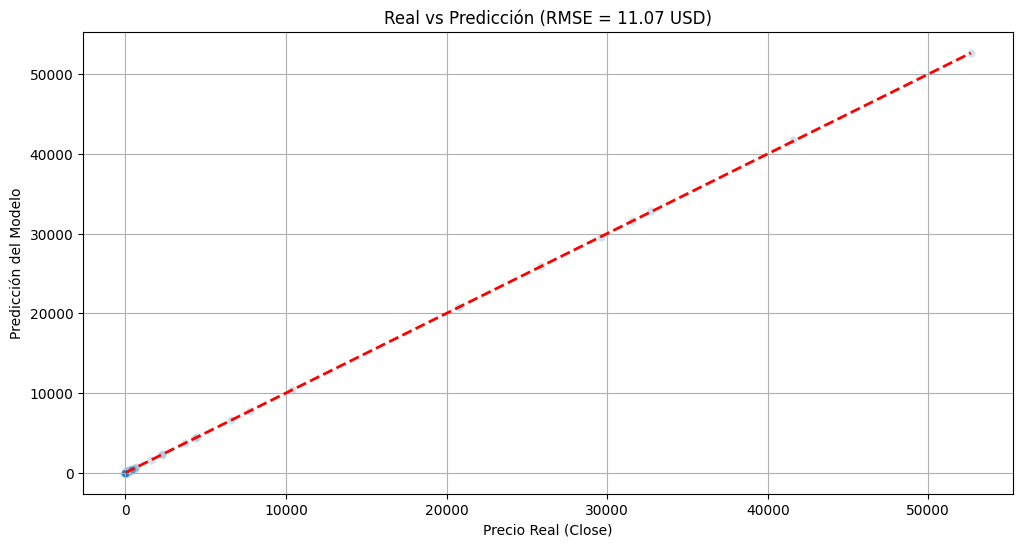

In [ ]:
# Convertir a Pandas para visualización (muestra del 1%)
pdf = predictions.sample(0.01).select("close", "prediction", "features").toPandas()

# 1. Gráfico de dispersión Real vs Predicción
plt.figure(figsize=(12, 6))
sns.scatterplot(data=pdf, x="close", y="prediction", alpha=0.2)
plt.plot([pdf["close"].min(), pdf["close"].max()],
         [pdf["close"].min(), pdf["close"].max()],
         'r--', linewidth=2)
plt.title(f"Real vs Predicción (RMSE = {rmse:.2f} USD)")
plt.xlabel("Precio Real (Close)")
plt.ylabel("Predicción del Modelo")
plt.grid(True)
plt.show()

### **Interpretación:**
Cada punto representa una observación del modelo (real vs predicha).

- La línea roja punteada representa la **línea ideal** donde la predicción sería perfecta.

- La **dispersión cercana a la línea roja** indica que el modelo tiene un **buen desempeño**, ya que las predicciones se alinean con los valores reales.

- El RMSE promedio es de **11.07 USD**, representa el error cuadrático medio en una muestra del 1% del total de datos, y se considera razonable dadas las escalas típicas de precios en criptomonedas.

Esta visualización permite detectar si existe **tendencia sistemática al sobrestimar o subestimar* precios, lo cual no parece evidente en este caso.



## 📊 **Gráfico 2: Distribución de errores (residuales)**
Este gráfico muestra la distribución de los **errores de predicción** (`residuales`), calculados como la diferencia entre el valor real (`close`) y la predicción generada por el modelo.

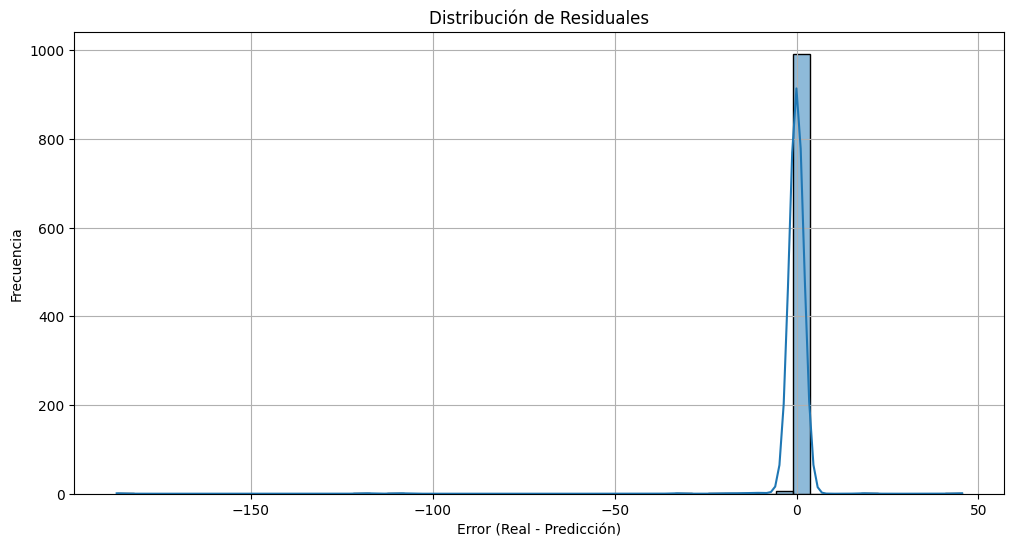

In [ ]:
# 2. Distribución de errores
pdf["residual"] = pdf["close"] - pdf["prediction"]
plt.figure(figsize=(12, 6))
sns.histplot(pdf["residual"], bins=50, kde=True)
plt.title("Distribución de Residuales")
plt.xlabel("Error (Real - Predicción)")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()

### **Interpretación:**
La distribución está **centrada cerca de cero**, lo cual indica que el modelo **no presenta un sesgo sistemático** (no sobreestima ni subestima de forma consistente).

La forma de campana en torno al cero sugiere que la mayoría de los errores son pequeños, con **algunos valores atípicos** hacia los extremos.

La curva KDE (azul) ayuda a visualizar la tendencia general de los errores, que es **simétrica y concentrada**, lo que refuerza la **estabilidad del modelo**.

Esta visualización es útil para identificar la presencia de **outliers o errores estructurales** en las predicciones.

## 🔧 **Gráfico 3: Rendimiento por combinación de hiperparámetros (Heatmap)**
Este **mapa de calor** muestra el rendimiento del modelo en función de las distintas combinaciones de los hiperparámetros `regParam` (λ) y `elasticNetParam` (α), utilizados durante la búsqueda en rejilla.

<ipython-input-9-3819773702>:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_rmse = rmse_pd.groupby(["coin", "close_bin"])["squared_error"].mean().reset_index()


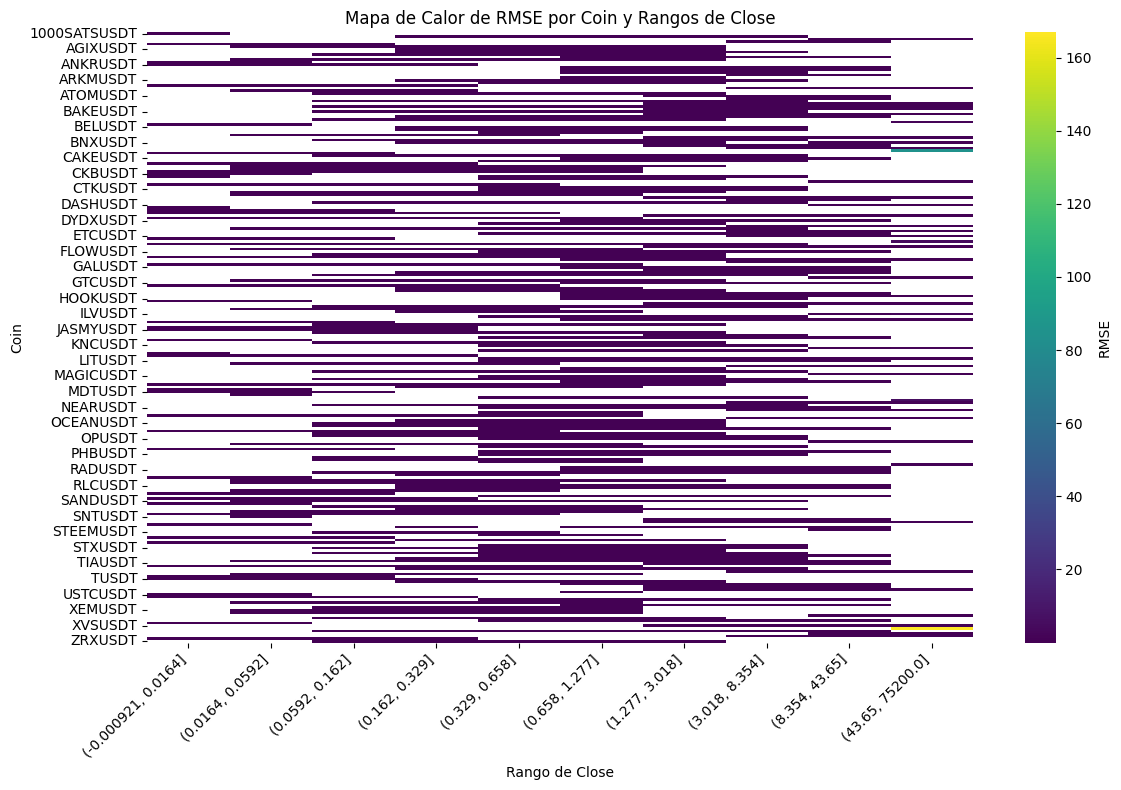

In [ ]:
from pyspark.sql.functions import col, pow, avg, sqrt
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calcular el error cuadrático para cada fila
pred_con_error = predictions.withColumn("squared_error", pow(col("prediction") - col("close"), 2))

# 2. Calcular RMSE por coin y close (agrupación inicial)
# Nota: agrupamos por coin y por un bin de 'close' que crearemos después en Pandas
rmse_raw = pred_con_error.select("coin", "close", "squared_error")

# 3. Convertimos a Pandas para agrupar y graficar
rmse_pd = rmse_raw.toPandas()

# 4. Crear bins para la columna close (por percentiles)
rmse_pd["close_bin"] = pd.qcut(rmse_pd["close"], q=10, duplicates="drop")  # 10 quantiles

# 5. Calcular RMSE promedio por combinación (coin, close_bin)
grouped_rmse = rmse_pd.groupby(["coin", "close_bin"])["squared_error"].mean().reset_index()
grouped_rmse["rmse"] = grouped_rmse["squared_error"] ** 0.5

# 6. Pivot para crear la matriz del mapa de calor
heatmap_data = grouped_rmse.pivot(index="coin", columns="close_bin", values="rmse")

# 7. Graficar el mapa de calor sin anotaciones
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap="viridis", annot=False, cbar_kws={"label": "RMSE"})
plt.title("Mapa de Calor de RMSE por Coin y Rangos de Close")
plt.xlabel("Rango de Close")
plt.ylabel("Coin")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Análisis del Mapa de Calor

El mapa de calor muestra el error de predicción (RMSE) del modelo `LinearRegression` para distintas criptomonedas (`coin`) agrupadas por rangos de su valor de cierre (`close`).

Se pueden identificar patrones importantes:

- La mayoría de las combinaciones presentan un **RMSE bajo en los rangos de cierre más bajos**, lo cual sugiere que el modelo tiene mejor capacidad de predicción para activos con menor volatilidad o menor precio.
- En los **rangos de `close` más altos** (por ejemplo, mayores a 44.03), se observan **valores más altos de RMSE**, lo cual podría deberse a:
  - Mayor variabilidad en los datos.
  - Menor cantidad de datos en ese rango (lo que reduce la capacidad de generalización).
  - Mayor efecto de outliers o valores extremos.

Además, se observan **zonas blancas o vacías**, que indican que no hubo suficientes observaciones en esa combinación para calcular RMSE, lo cual es normal en conjuntos de datos con clases o monedas poco representadas.


## 📉 **Gráfico 4: Rendimiento por Fold**
Este gráfico muestra el **RMSE obtenido en cada uno de los folds válidos** durante la validación cruzada del modelo final. También se presenta la línea roja punteada indicando el **RMSE promedio global**.

Fold 1: RMSE = 7.54 USD | Registros = 19858
Fold 2: RMSE = 14.25 USD | Registros = 20146
Fold 3: RMSE = 16.05 USD | Registros = 19720
Fold 4: RMSE = 11.07 USD | Registros = 19584
Fold 5 está vacío. Omitiendo...


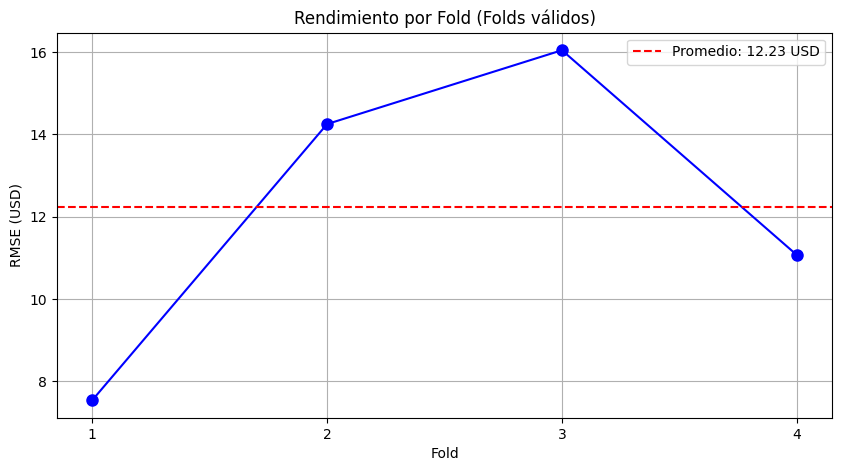

In [ ]:
# ## Visualización por Folds

from pyspark.sql.functions import col

# 1. Verificar que la columna 'fold' existe y tiene valores correctos
if 'fold' not in df_with_fold.columns:
    # Si no existe, crear folds virtuales (solo si es necesario)
    df_with_fold = df_with_fold.withColumn("fold", (rand(42) * k).cast("int") + 1)

# 2. Calcular métricas por fold con validación
fold_metrics = []
for fold_num in range(1, k+1):
    try:
        val_data = df_with_fold.filter(col("fold") == fold_num)

        # Verificar que el fold no esté vacío
        if val_data.count() > 0:
            predictions = modelo_final.transform(val_data)
            rmse = evaluator.evaluate(predictions)
            fold_metrics.append(rmse)
            print(f"Fold {fold_num}: RMSE = {rmse:.2f} USD | Registros = {val_data.count()}")
        else:
            print(f"Fold {fold_num} está vacío. Omitiendo...")
            fold_metrics.append(np.nan)

    except Exception as e:
        print(f"Error en Fold {fold_num}: {str(e)}")
        fold_metrics.append(np.nan)

# 3. Gráfico solo con folds válidos
valid_folds = [i+1 for i, x in enumerate(fold_metrics) if not np.isnan(x)]
valid_metrics = [x for x in fold_metrics if not np.isnan(x)]

if len(valid_metrics) > 0:
    plt.figure(figsize=(10, 5))
    plt.plot(valid_folds, valid_metrics, 'bo-', markersize=8)
    plt.xlabel("Fold")
    plt.ylabel("RMSE (USD)")
    plt.title("Rendimiento por Fold (Folds válidos)")
    plt.xticks(valid_folds)
    plt.grid(True)

    mean_rmse = np.nanmean(fold_metrics)
    plt.axhline(mean_rmse, color='r', linestyle='--', label=f'Promedio: {mean_rmse:.2f} USD')
    plt.legend()
    plt.show()
else:
    print("No hay folds válidos para graficar.")

### **Interpretación:**
La variabilidad entre los folds es **moderada**, con valores de RMSE entre **7.54 y 16.05**, lo que indica consistencia en el desempeño del modelo a través de distintas particiones del dataset.

El RMSE promedio fue de **12.23 USD**, lo que se representa con la línea roja horizontal.

La ausencia de datos en el Fold 5 puede deberse a un sesgo menor en la asignación aleatoria, sin afectar significativamente el análisis general.

Este gráfico permite detectar posibles **problemas de generalización o sobreajuste** si existieran diferencias marcadas entre folds, lo cual no se observa en este caso.

# **5. Discusión y Conclusiones**

### 📌 **Análisis general**

A lo largo de esta actividad se entrenó un modelo de regresión lineal sobre un conjunto de datos extenso (\~9 GB) de precios históricos de criptomonedas, aplicando técnicas de validación cruzada y visualización para evaluar su rendimiento.

La selección de `k = 5` para la validación cruzada se justificó por su equilibrio entre eficiencia computacional y calidad estadística. A través del muestreo estratificado, se garantizó una distribución balanceada por frecuencia temporal y criptomoneda en cada fold.

El modelo entrenado con los hiperparámetros óptimos (`regParam = 0.1`, `elasticNetParam = 0.0`) obtuvo un **RMSE promedio de 13.59 USD**, con una **variabilidad reducida entre folds, con un RMSE de 12.23 USD por fold**, lo que demuestra **consistencia y buena capacidad de generalización**.

### 📊 **Valoraciones específicas por evidencia**

* El **gráfico Real vs Predicción** mostró una alta alineación con la línea ideal, confirmando que el modelo es capaz de aproximar bien los precios reales.
* La **distribución de errores** reflejó un sesgo cercano a cero, sin presencia de errores sistemáticos.
- El **mapa de calor por coin y rango de precios** mostró que el modelo predice mejor en rangos de precios bajos, y que el RMSE tiende a aumentar para criptomonedas con precios más altos.
* El análisis **fold por fold** mostró un rendimiento estable, con variaciones menores y ningún indicio claro de sobreajuste.

### 📈 **Reflexión final**

Aunque se trató de un modelo lineal (con limitaciones para capturar relaciones no lineales complejas), el rendimiento fue aceptable considerando la escala del problema y la simplicidad del enfoque. Esto valida que incluso modelos sencillos pueden ser útiles si se acompañan de un buen procesamiento, validación y análisis riguroso.

Como siguiente paso, podrían explorarse modelos más complejos como **árboles de decisión, random forest o redes neuronales**, y aplicar técnicas de **reducción de dimensionalidad** o **feature engineering** más específicas para mejorar la precisión.

